Por desarrollar
===============

**Author:** Marcos Bujosa



$
\newcommand{\R}[1][{}]{{\mathbb{R}}^{#1}}
\newcommand{\Z}[1][{}]{{\mathbb{Z}}^{#1}}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\getItem}{{\mid}}
\newcommand{\getitemR}[1]{\getItem{#1}}
\newcommand{\getitemL}[1]{{#1}\getItem}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\elemR}[2]{{#1}^{\phantom{\T}}_{\getitemR{#2}}} 
\newcommand{\elemRP}[2]{{\big(#1\big)}^{\phantom{\T}}_{\getitemR{#2}}} 
\newcommand{\elemRPE}[2]{\big({#1}^{\phantom{\T}}_{\getitemR{#2}}\big)}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\elemL}[2]  { {\vphantom{#1}}_{ \getitemL{#2}} {#1} } 
\newcommand{\elemLP}[2] { \elemL{\!\big({#1}\big)}{#2} }  
\newcommand{\elemLPE}[2]{ \big(\elemL{#1}{#2}\big) }
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\Vect}[2][{}]{{\boldsymbol{#2}}_{#1}}
\newcommand{\eleVR}[2]  {\elemR  {\Vect{#1}}{#2}}      % con subindices
\newcommand{\eleVRP}[2] {\elemRP {\Vect{#1}}{#2}}      % con subindices y paréntesis interior
\newcommand{\eleVRPE}[2]{\elemRPE{\Vect{#1}}{#2}}      % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\VectC}[2]  {\elemR  {\Mat{#1}}{#2}}         % con subindices
\newcommand{\VectCP}[2] {\elemRP {\Mat{#1}}{#2}}       % con subindices y paréntesis
\newcommand{\VectCPE}[2]{\elemRPE{\Mat{#1}}{#2}}       % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\VectF}[2]  {\elemL  {\Mat{#1}}{#2}}         % con subindices
\newcommand{\VectFP}[2] {\elemLP {\Mat{#1}}{#2}}       % con subindices y paréntesis
\newcommand{\VectFPE}[2]{\elemLPE{\Mat{#1}}{#2}}       % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\mat}[1]{\mathbf{#1}}
%\newcommand{\mat}[1]{\boldsymbol{#1}}                 % hace cursiva, no me gusta para matriz
\newcommand{\Mat} [2][{}]{{\mat{#2}}_{#1}} 
\newcommand{\T}{\intercal}
\newcommand{\MatT}[2][{}]{{\mat{#2}}^{\T}_{#1}}
\newcommand{\VectCC}[2][{}]   {\elemRR {\Mat{#2}}{#1}}   % con ()
\newcommand{\VectCCC}[2][{}]  {\elemRRR{\Mat{#2}}{#1}}   % con texto "col"
%SELECCIÓNA de FILAS y COlUMNAS DE UNA MATRIZ TRANSPUESTA PARA GENERAR UN VECTOR DE Rn
\newcommand{\VectTC}[2][{}]   {\elemR{\MatT{#2}\!}{#1}}  % con subindices
\newcommand{\VectTCC}[2][{}]  {\elemRR{ \MatT{#2}}{#1}}  % con ()
\newcommand{\VectTCCC}[2][{}] {\elemRRR{\MatT{#2}}{#1}}  % con texto "col"
\newcommand{\dotprod}[2][{}] {\Vect{#1}\cdot\Vect{#2}}
\newcommand{\concat}{\mathbin{-\mkern-9.5mu\lVert}}
\newcommand{\SEL}[2] { \Mat{#1}\Vect{x}=\Vect{#2} }
\newcommand{\EV}[1]{\mathcal{#1}}
\newcommand{\SV}[1]{\mathsf{#1}}
$

Para usar [NAcAL](https://github.com/mbujosab/nacallib), es necesario importar el módulo `nacal`.



In [1]:
from nacal import *

Quedan muchas cosas por ver con NAcAL. En lugar de seguir el libro, iré exponiendo algunas. Ya desarrollaré mejor este cuaderno en el futuro.



## Resolución de sistemas de ecuaciones lineales homogéneos



Por ejemplo, sea la matriz



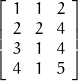

In [2]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

Hagamos eliminación de izquierda a derecha por columnas para obtener una forma preescalonada de la matriz:



In [3]:
K = A.K(True)

<IPython.core.display.Math object>

Claramente, la última columna es combinación lineal de las anteriores. 
Para encontrar la combinación lineal basta recordar que 
$$
\Mat{K}
=
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{A}
=
\Mat{A}
\big(
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}
\big)
$$
por tanto, si $\elemR{\Mat{K}}{j}=\Vect{0}$, la columna $j$-ésima de $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ es un vector del espacio nulo de $\Mat{A}$
ya que
$$
 \elemR{\Mat{K}}{j} = \Mat{A} \elemRP{\Mat[\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}]{I}}{j}=\Vect{0}.
$$

Así pues, creamos una lista con los índices de las columnas nulas de $\Mat{K}$:



In [4]:
indiceColumnasNulasdeK = [j for j,c in enumerate(K, 1) if c.es_nulo()]
indiceColumnasNulasdeK

[3]

Para calcular $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ necesitamos conocer la secuencia ${\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}$ de transformaciones elementales que hemos aplicado sobre las columnas de $\Mat{A}$ para obtener la forma pre-escalonada $\Mat{K}$. Dicha secuencia está almacenada en el atributo `TrC` de `K`:



In [5]:
K.TrC

T([(-1, 1, 2), (-2, 1, 3), (-1, 2, 3)])

Para abreviar, llamemos $\Mat{E}$ a dicha matriz $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$:



In [6]:
E = I( A.n ) & K.TrC

Las columnas de $\Mat{E}$ cuyos índices aparezcan en `indiceColumnasNulasdeK` son soluciones del sistema $\Mat{A}\Vect{x}=\Vect{0}$. En este caso:



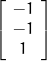

In [7]:
E|indiceColumnasNulasdeK

Veámoslo



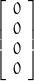

In [8]:
A * (E|indiceColumnasNulasdeK)

## Resolución de sistemas de ecuaciones lineales homogéneos con `Homogenea`



La clase `Homogenea` resuelve sistemas de ecuaciones lineales homogéneos siguiendo el anterior procedimiento. 
El argumento necesario es un sistema de vectores (generalmente una matriz). 
La respuesta que muestra es el espacio nulo asociado al sistema de vectores. 
Si dicho subespacio solo contiene al vector nulo, se muestra el conjunto que contiene dicho vector. Por ejemplo, si el argumento es una matriz de rango completo por columnas como la matriz identidad obtenemos:



In [9]:
Homogenea(I(4))

Combinaciones lineales de (Sistema([Vector([0, 0, 0, 0]);]))

Si las columnas de la matriz son linealmente dependientes, nos indica que el conjunto de vectores del espacio nulo es la envolvente lineal (o span) del sistema que contiene las soluciones especiales (las que encontramos mediante la eliminación por columnas de izquierda a derecha con el procedimiento descrito más arriba):



In [10]:
Homogenea(A)

Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

Cuando damos un segundo argumento, que no sea `0` ó `False`, nos muestra los pasos seguidos hasta la resolución. 
Para mostrar los pasos sigue el mismo procedimiento que hemos visto en clase, apilando el sistema sobre una matriz identidad de orden igual al número de elementos del sistema dado como argumento (normalmente las columnas de la matriz).



In [11]:
Homogenea(A, True)

<IPython.core.display.Math object>

Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

### Atributos de `Homogenea`



La clase `Homogenea` tiene distintos atributos. 

-   `enulo` es el espacio nulo asociado al sistema dado como argumento. Es un objeto de la clase `SubEspacio` de nacal.
-   `base` es una base del espacio nulo
-   `sgen` es un sistema generador del espacio nulo (es el que usa nacal para expresar el subespacio con unas ecuaciones paramétricas). Es igual a `base` (salvo cuando la dimensión del espacio nulo es 0; en tal caso `base` es un sistema vacío mientras que `sgen` es un sistema con un único vector nulo).
-   `determinado` vale 1 cuando la dimensión del espacio nulo es 0 (y 0 en caso contrario).
-   `pasos` es una lista con dos sublistas: la primera contiene las transformaciones aplicadas a las filas (vacía si operamos por columnas) y la segunda sublista contiene las transformaciones aplicadas a las columnas.
-   `TrF` es un objeto de la clase `T` con las transformaciones aplicadas a las filas (vacío si operamos por columnas)
-   `TrC` es un objeto de la clase `T` con las transformaciones aplicadas a las columnas.
-   `tex` es una cadena de texto con el código $\LaTeX{}$ necesario para mostrar la resolución paso a paso: muestra el sistema apilado sobre una matriz identidad del mismo orden que el número de elementos del sistema (con una recta horizontal de separación entre el sistema y la matriz identidad). Se muestran los pasos dados al aplicar las transformaciones elementales necesarias para obtener un sistema pre-escalonado (sobre la recta horizontal), y las sucesivas matrices que se obtienen al aplicar los mismos pasos sobre las columnas de la matriz identidad (debajo).

Veámoslo con distintos ejemplos.



#### Sistema indeterminado



In [12]:
SistEcuacionesH1 = Homogenea(A)
SistEcuacionesH1.enulo

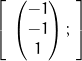

In [13]:
SistEcuacionesH1.base

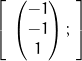

In [14]:
SistEcuacionesH1.sgen

In [15]:
SistEcuacionesH1.determinado

False

In [16]:
SistEcuacionesH1.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3)]), T([(-1, 2, 3)])]]

In [17]:
SistEcuacionesH1.TrC

T([(-1, 1, 2), (-2, 1, 3), (-1, 2, 3)])

#### Sistema determinado



In [18]:
SistEcuacionesH2 = Homogenea( Matrix([[1,1],[1,1],[1,2]]), True)

<IPython.core.display.Math object>

In [19]:
SistEcuacionesH2.enulo

In [20]:
SistEcuacionesH2.base

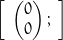

In [21]:
SistEcuacionesH2.sgen

In [22]:
SistEcuacionesH2.determinado

True

In [23]:
SistEcuacionesH2.pasos

[[], [T([(-1, 1, 2)])]]

In [24]:
SistEcuacionesH2.TrC

T([(-1, 1, 2)])

## Resolución de sistemas de ecuaciones lineales genéricos



Por ejemplo, sea la matriz



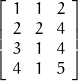

In [25]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

y los vectores



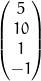

In [26]:
b = Vector([5,10,1,-1])
b

y



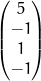

In [27]:
d = Vector([5,-1,1,-1])
d

#### Ejemplo de sistema compatible



Vamos a resolver $\Mat{A}\Vect{x}=\Vect{b}$. 
El sistema tiene solución si $\Vect{b}$ es igual a alguna combinación lineal de las columnas de $\Mat{A}$. Si $\Vect{x}$ está formado por los parámetros de alguna de esas combinaciones lineales, entonces $\Mat{A}\Vect{x}-\Vect{b}=\Vect{0}$; es decir, si al añadir $\Mat{A}\Vect{x}$ a $-\Vect{b}$ obtenemos un vector nulo, entonces $\Vect{x}$ es una solución del sistema, puesto que entonces $\Mat{A}\Vect{x}=\Vect{b}$. 

Primero ampliamos $\Mat{A}$ con una columna adicional.



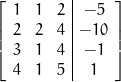

In [28]:
M = A.amplia(-b, 1)
M

Ahora pre-escalonamos la matriz ampliada, es decir, añadimos a las columnas de la derecha combinaciones lineales de las columnas que están a su izquierda, tratando de generar ceros a la derecha de cada pivote:



In [29]:
K = M.K(1)

<IPython.core.display.Math object>

Dado que las dos últimas columnas se han anulado, sabemos que la última columna de $\Mat{A}$ es combinación lineal de las dos primeras (ya lo vimos más arriba). Lo que ahora nos interesa es que la última columna de la matriz ampliada también se ha anulado. Por tanto, ahora sabemos que $\Vect{b}$ es una combinación lineal de las columnas de $\Mat{A}$; es decir, que el sistema tiene solución (que es compatible).

Para encontrar una solución razonamos de manera similar a como hicimos más arriba. 
De nuevo recordamos que 
$$
\Mat{K}
=
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{M}
=
\Mat{M}
\big(
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}
\big)
$$
por tanto, si la última columna $\elemR{\Mat{K}}{n}=\Vect{0}$, entonces

$$
 \elemR{\Mat{K}}{n} = \Mat{M} \elemRP{\Mat[\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}]{I}}{n}=\Vect{0}.
$$

Para calcular $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ necesitamos conocer la secuencia ${\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}$ de transformaciones elementales que hemos aplicado sobre las columnas de $\Mat{M}$ para obtener la forma pre-escalonada $\Mat{K}$. Como antes, dicha secuencia está almacenada en el atributo `TrC` de la matriz preescalonada `K`:



In [30]:
K.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

Para abreviar, llamemos $\Mat{E}$ a dicha matriz $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$:



In [31]:
E = I( A.m ) & K.TrC

De tal manera que la última columna de $\Mat{E}$ es tal que multiplicada por la matriz ampliada nos da un vector nulo:



In [32]:
M * (E|0)

Por tanto, la última columna de $\Mat{E}$ nos da una combinación lineal de las columnas de $\Mat{A}$ y del vector $-\Vect{b}$ que es cero, es decir



In [33]:
operaciones = "+".join(['(' + (latex((E|0)|i)) + ')' + latex(M|i) for i,c in enumerate(M,1)])
display(Math(operaciones + '=' + latex(V0(M.m))))

<IPython.core.display.Math object>

Es decir, como la última columna de $\Mat{M}$ es $-\Vect{b}$, quiere decir que



In [34]:
operaciones = "+".join(['(' + (latex((E|0)|i)) + ')' + latex(M|i) for i,_ in enumerate(A,1)])
display(Math(operaciones + '=(' + latex((E|0)|0) + r')\Vect{b}'))

<IPython.core.display.Math object>

(fíjese que es importante tener en cuenta el coeficiente que ocupa la última posición de la última columna de $\Mat{E}$, pues indica si la combinación lineal de la izquierda es igual a $\Vect{b}$ o a un múltiplo de $\Vect{b}$).

La solución completa es el conjunto de vectores que son de la forma: la solución particular que hemos encontrado más cualquier vector del espacio nulo de la matriz de coeficientes (es decir, un espacio afín).



#### Ejemplo de sistema incompatible



Tratemos de resolver $\SEL{A}{d}$. Primero ampliamos $\Mat{A}$ con $-\Vect{d}$ como una última columna adicional.



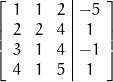

In [35]:
N = A.amplia(-d, 1)
N

Ahora pre-escalonamos la matriz ampliada, es decir, añadimos a las columnas de la derecha combinaciones lineales de las columnas que están a su izquierda, tratando de generar ceros a la derecha de cada pivote:



In [36]:
K = N.K(1)

<IPython.core.display.Math object>

Dado que la última columna de la forma preescalonada no es nula, sabemos que la última columna de $\Mat{M}$ (el vector $\Vect{d}$) no es combinación lineal de las primeras columnas (las columnas de $\Mat{A}$); es decir, el sistema no tiene solución (es incompatible).



## Resolución de sistemas de ecuaciones lineales con `SEL`



La clase `SEL` (Sistema de Ecuaciones Lineales) resuelve sistemas de ecuaciones lineales. Los argumentos que necesita son un sistema de vectores (generalmente una matriz) y un vector del lado derecho (del mismo tipo que los elementos del sistema dado). 
Si añadimos un tercer argumento que no sea `0` ó `False`, nos mostrará los pasos seguidos hasta la resolución, tal como hemos aprendido en clase.

Por ejemplo, sea la matriz



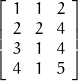

In [37]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

y los vectores



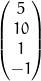

In [38]:
b = Vector([5,10,1,-1])
b

y



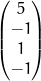

In [39]:
d = Vector([5,-1,1,-1])
d

Vamos a resolver $\Mat{A}\Vect{x}=\Vect{b}$



In [40]:
SEL(A,b)

Vector([-2, 7, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

Es decir, el sistema tiene infinitas soluciones.

Veamos que, efectivamente, en la matriz ampliada se anula la última columna (y que, por tanto, el vector $\Vect{b}$ es una combinación lineal de las columnas de $\Mat{A}$).



In [41]:
SEL(A,b, True)   # donde True es para que nos muestre los pasos

<IPython.core.display.Math object>

Vector([-2, 7, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

Resolvamos ahora $\Mat{A}\Vect{x}=\Vect{d}$



In [42]:
SEL(A,d)

set() + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

Como se puede ver, el sistema no tiene solución (o, dicho de otra forma: el conjunto de soluciones es vacío, $\emptyset$).

Veamos que, efectivamente, en la matriz ampliada NO se anula la última columna (y que, por tanto, el vector $\Vect{d}$ NO es una combinación lineal de las columnas de $\Mat{A}$).



In [43]:
SEL(A,d, True)   # donde True es para que nos muestre los pasos

<IPython.core.display.Math object>

set() + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

### Atributos de `SEL`



La clase `SEL` tiene distintos atributos. 

-   `eafin` es el conjunto de soluciones. Hay dos casos:
    -   Si el conjunto tiene infinitas soluciones es un espacio afín (clase `EAfin` de nacal).
    -   Si no hay solución, es un conjunto vacío.
-   `solP` es una solución particular.
    -   Si el conjunto tiene infinitas soluciones, es el vector usado al expresar las ecuaciones paramétricas.
    -   Si no hay solución, es un conjunto vacío.
-   `base` es una base del espacio nulo de la matriz de coeficientes (es la usada al expresar las ecuaciones paramétricas).
-   `sgen` es un sistema generador del espacio nulo de la matriz de coeficientes (es la usada al expresar las ecuaciones paramétricas). Es igual a `base` salvo cuando la dimensión del espacio nulo es 0; en ese caso, `sgen` es un sistema con un único vector nulo.
-   `determinado` vale 1 cuando la dimensión del espacio nulo es 0, y vale 0 en caso contrario.
-   `pasos` es una lista con dos sublistas: la primera contiene las transformaciones aplicadas a las filas (vacía si operamos por columnas) y la segunda sublista contiene las transformaciones aplicadas a las columnas.
-   `TrF` es un objeto de la clase `T` con las transformaciones aplicadas a las filas (vacío si operamos por columnas).
-   `TrC` es un objeto de la clase `T` con las transformaciones aplicadas a las columnas.
-   `tex` es una cadena de texto con el código $\LaTeX{}$ con la resolución paso a paso.

Veámoslo con distintos ejemplos.



#### Sistema compatible indeterminado



In [44]:
SistEcuaciones1 = SEL(A, b, True)

<IPython.core.display.Math object>

Al solicitar `eafin` nos muestra dos representaciones: la primera con unas ecuaciones paramétricas, y la segunda con unas cartesianas:



In [45]:
SistEcuaciones1.eafin

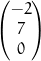

In [46]:
SistEcuaciones1.solP

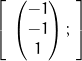

In [47]:
SistEcuaciones1.base

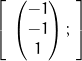

In [48]:
SistEcuaciones1.sgen

In [49]:
SistEcuaciones1.determinado

False

In [50]:
SistEcuaciones1.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4)]), T([(-1, 2, 3), (7, 2, 4)])]]

In [51]:
SistEcuaciones1.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

#### Sistema incompatible



Ahora con un sistema sin solución



In [52]:
SistEcuaciones2 = SEL(A, d, True)

<IPython.core.display.Math object>

Al solicitar `eafin` nos muestra dos representaciones: la primera con unas ecuaciones paramétricas, y la segunda con unas cartesianas:



In [53]:
SistEcuaciones2.eafin

set()

In [54]:
SistEcuaciones2.solP

set()

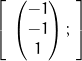

In [55]:
SistEcuaciones2.base

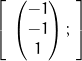

In [56]:
SistEcuaciones2.sgen

In [57]:
SistEcuaciones2.determinado

False

In [58]:
SistEcuaciones2.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4)]), T([(-1, 2, 3), (7, 2, 4)])]]

In [59]:
SistEcuaciones2.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

#### Sistema compatible determinado



In [60]:
SistEcuaciones3 = SEL(I(3), Vector([1,2,3]), True)

<IPython.core.display.Math object>

Al solicitar `eafin` nos muestra dos representaciones: la primera con unas ecuaciones paramétricas, y la segunda con unas cartesianas:



In [61]:
SistEcuaciones3.eafin

In [62]:
SistEcuaciones3.solP

In [63]:
SistEcuaciones3.base

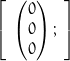

In [64]:
SistEcuaciones3.sgen

In [65]:
SistEcuaciones3.determinado

True

In [66]:
SistEcuaciones3.pasos

[[], [T([(1, 1, 4)]), T([(2, 2, 4)]), T([(3, 3, 4)])]]

In [67]:
SistEcuaciones3.TrC

T([(1, 1, 4), (2, 2, 4), (3, 3, 4)])

#### Incompatible con espacio nulo trivial



In [68]:
SistEcuaciones4 = SEL( I(3)|(1,2), Vector([1,2,3]), True)

<IPython.core.display.Math object>

Al solicitar `eafin` nos muestra dos representaciones: la primera con unas ecuaciones paramétricas, y la segunda con unas cartesianas:



In [69]:
SistEcuaciones4.eafin

set()

In [70]:
SistEcuaciones4.solP

set()

In [71]:
SistEcuaciones4.base

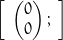

In [72]:
SistEcuaciones4.sgen

In [73]:
SistEcuaciones4.determinado

True

In [74]:
SistEcuaciones4.pasos

[[], [T([(1, 1, 3)]), T([(2, 2, 3)])]]

In [75]:
SistEcuaciones4.TrC

T([(1, 1, 3), (2, 2, 3)])

## Otros sistemas de ecuaciones



Este método es válido incluso con otro tipo de espacios vectoriales de dimensión finita. Por ejemplo, las matrices 3 por 2.

Sean las siguientes matrices:



In [76]:
A = Matrix([[1,2],[1,1],[0,1]])
B = Matrix([[1,1],[1,4],[1,1]])
D = Matrix([[2,3],[2,5],[1,2]])
C = Matrix([[0,1],[1,0],[0,0]])

Con ellas podemos construir el siguiente sistema



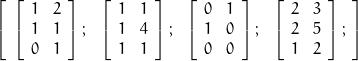

In [77]:
S = Sistema([A,B,C,D])
S

El conjunto de sus combinaciones lineales es un subespacio. Podemos pedir a NAcAL que nos muestre unas ecuaciones paramétricas y otras cartesianas para dicho subespacio.



In [78]:
V = SubEspacio(S)
V

(donde $vec(\Mat{M})$ es el vector que se obtiene al apilar las columnas de la matriz $\Mat{M}$ en un único vector).

Consideremos la matriz



In [79]:
F = Matrix([Vector([6, 8, 2]), Vector([12, 12, 6])])

La librería NAcAL usa las ecuaciones cartesianas de más arriba para verificar si un determinado vector (en este ejemplo dicho vector es una matriz) pertenece, o no, al subespacio vectorial correspondiente a dichas ecuaciones (en este caso, un espacio vectorial cuyos elementos son matrices).
Por ejemplo, podemos preguntar si $\Mat{F}$ es un elemento de $\EV{V}$



In [80]:
F in SubEspacio(S)

True

Puesto que es verdad que $\Mat{F}$ pertenece al subespacio, podemos intentar resolver $\SV{S}\Vect{x}=\Mat{F}$:



In [81]:
SEL(S, F, True)

<IPython.core.display.Math object>

Vector([4, 2, 2, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 0, 1]);]))

Este resultado nos dice dos cosas, cómo combinar las matrices de $\SV{S}$ para obtener matrices nulas:



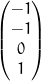

In [82]:
n = SEL(S, F).base|1
n

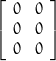

In [83]:
S * n

y cómo combinar las matrices de $\SV{S}$ para obtener $\Mat{F}$.



In [84]:
xp = SEL(S, F).solP
xp

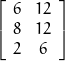

In [85]:
S * xp

Pero entonces también es solución



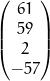

In [86]:
v = xp+-57*n
v

como se puede comprobar:



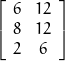

In [87]:
S * v

es decir



In [88]:
operaciones = "+".join(['(' + latex(c) + ')' + latex(S|i) for i,c in enumerate(v,1)])
display(Math(operaciones + '=' + latex(F)))

<IPython.core.display.Math object>

## Los cuatro espacios fundamentales



Sea la matriz



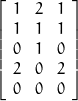

In [89]:
A = Matrix([[1,2,1],[1,1,1],[0,1,0],[2,0,2],[0,0,0]])
A

Vista como un sistema de vectores es



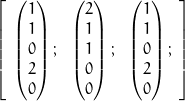

In [90]:
A.sis()

¿Qué espacio genera esta lista de columnas?



In [91]:
Cols = SubEspacio( A.sis() )
Cols

¿Cuál es su espacio nulo?



In [92]:
Enulo = SubEspacio( A )
Enulo

Por tanto, su espacio fila es



In [93]:
Fila = SubEspacio( (~A).sis() )
Fila

o lo que es lo mismo, el complemento ortogonal del espacio nulo



In [94]:
~Enulo

Y su espacio nulo por la izquierda es



In [95]:
EnuloIzda = SubEspacio( ~A )
EnuloIzda

o lo que es lo mismo, el complemento ortogonal del espacio columna



In [96]:
~Cols

El atributo `Rn` nos indica de quién son subespacios



In [97]:
print(Cols.Rn)
print(EnuloIzda.Rn)
print(Fila.Rn)
print(Enulo.Rn)

5
5
3
3


$\R[5]$ es el espacio vectorial generado por las 5 columnas de la matriz identidad de orden 5



In [98]:
R5 = SubEspacio( I(5).sis() )

Veamos que $\R[5]$ es suma directa del espacio columna y el nulo por la izquierda de la matriz $\Mat{A}$. Por una parte



In [99]:
R5 == Cols + EnuloIzda

True

y su intersección solo contiene el cero



In [100]:
Cols & EnuloIzda

Vea cómo las dimensiones concuerdan



In [101]:
Sistema([Cols.dim, EnuloIzda.dim, (Cols+EnuloIzda).dim])

**Ejercicio**: *Repita estas comprobaciones, pero ahora con el espacio fila y el nulo de la matriz $\Mat{A}$ para ver que su suma directa es $\R[3]$.*



## Determinante



In [102]:
A = Matrix([
    [2, 0, 3, 2],
    [5, 1, 2, 4],
    [3, 0, 1, 2],
    [5, 3, 2, 1]])

In [103]:
A.determinante()

29

In [104]:
Determinante(A, True)

<IPython.core.display.Math object>

Valor del determinante: 29